In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dbcv import dbcv
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from clustergram import Clustergram
from yellowbrick.cluster import KElbowVisualizer

In [2]:
df = load_iris()
X = df.data
y = df.target

**Кластерграм:**

K=2 fitted in 0.482 seconds.
K=3 fitted in 0.006 seconds.
K=4 fitted in 0.002 seconds.
K=5 fitted in 0.002 seconds.
K=6 fitted in 0.002 seconds.
K=7 fitted in 0.003 seconds.
K=8 fitted in 0.002 seconds.
K=9 fitted in 0.002 seconds.
K=10 fitted in 0.003 seconds.


<Axes: xlabel='Number of clusters (k)', ylabel='PCA weighted mean of the clusters'>

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

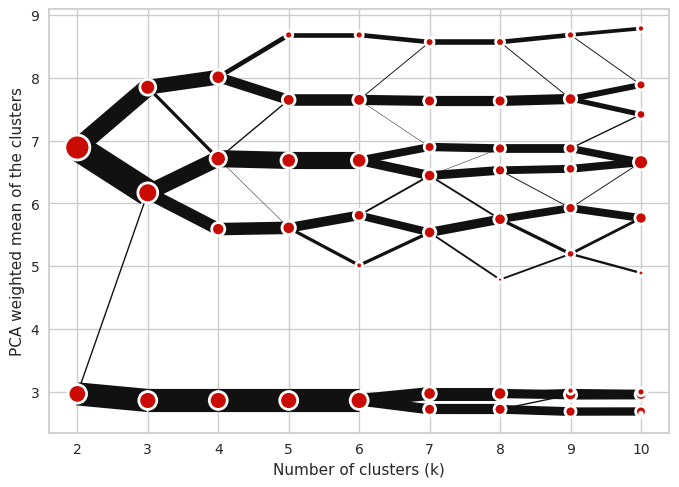

In [3]:
cgram = Clustergram(range(2, 11))
cgram.fit(X)
cgram.plot()

Бачимо, що вже на трьох кластерах данні стрибають, тому мабуть краще залишитися на двох, перевіримо через графік скоров

In [4]:
clusters_kmeans = []
for i in range(2, 11):
	kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto').fit(X)
	score = silhouette_score(X, kmeans.labels_)
	clusters_kmeans.append(score)
print("Найкраща кількість кластерів для KMeans:", clusters_kmeans.index(max(clusters_kmeans)) + 2, f"({max(clusters_kmeans)})")

Найкраща кількість кластерів для KMeans: 2 (0.6810461692117462)


In [5]:
clusters_agglomerative = []
for i in range(2, 11):
	agglomerative = AgglomerativeClustering(n_clusters=i).fit(X)
	score = silhouette_score(X, agglomerative.labels_)
	clusters_agglomerative.append(score)
print("Найкраща кількість кластерів для AgglomerativeClustering:", clusters_agglomerative.index(max(clusters_agglomerative)) + 2, f"({max(clusters_agglomerative)})")

Найкраща кількість кластерів для AgglomerativeClustering: 2 (0.6867350732769776)


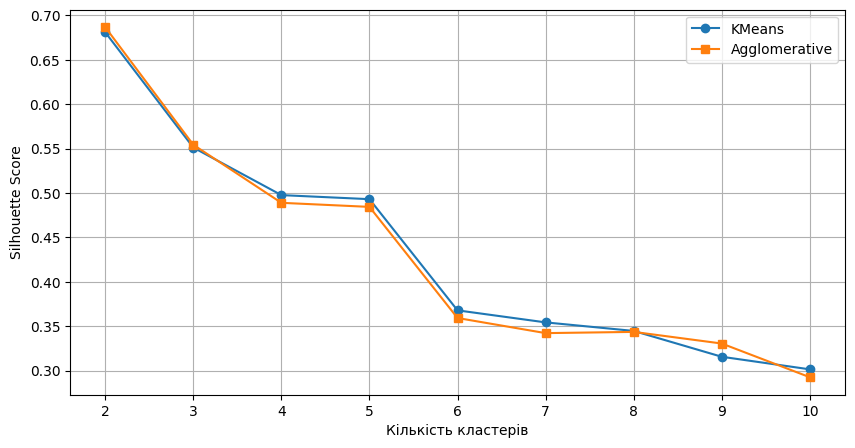

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), clusters_kmeans, marker='o', label='KMeans')
plt.plot(range(2, 11), clusters_agglomerative, marker='s', label='Agglomerative')

plt.xlabel('Кількість кластерів')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid()
plt.show()

І для кластеризації поділом і для ієрархічної найраще буде мати 2 кластери.

Подивимось на метод ліктя:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

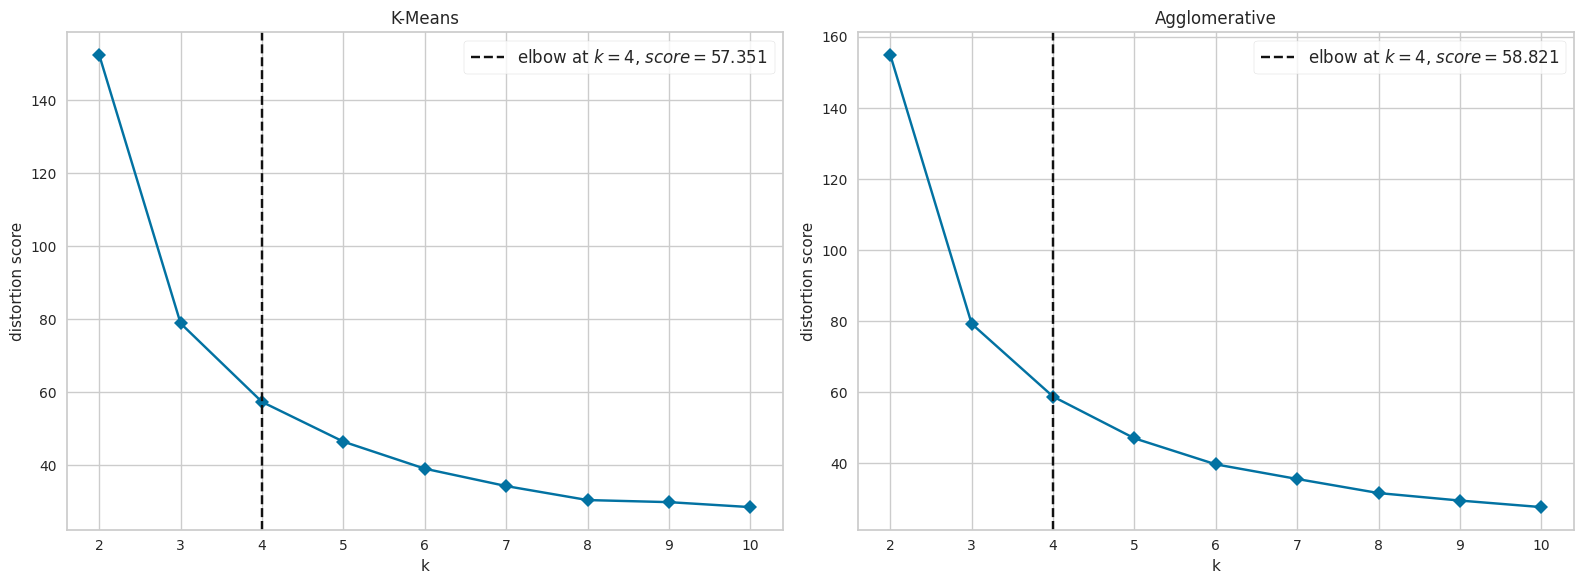

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KMeans
model = KMeans(random_state=42, n_init='auto')
model._estimator_type = "clusterer"

visualizer = KElbowVisualizer(model, k=(2, 11), timings=False, ax=axes[0])
visualizer.fit(X)
visualizer.finalize() 
axes[0].set_title("K-Means")

# AgglomerativeClustering
model = AgglomerativeClustering()
model._estimator_type = "clusterer"

visualizer = KElbowVisualizer(model, k=(2, 11), timings=False, ax=axes[1])
visualizer.fit(X)
visualizer.finalize()
axes[1].set_title("Agglomerative")

plt.tight_layout()
plt.show()

Метод ліктя говорить, що краще використовувати 4 кластери, це як варіант

Тепер подивимось на DBSCAN и для метрики буду використовувати [DBCV](https://github.com/FelSiq/DBCV)

In [ ]:
X_unique = np.unique(X, axis=0, return_index=False) # Видаляємо дублікати для dbcv

clusters_dbscan = dict()
for i in np.arange(0.1, 2.0, 0.1):
    for j in range(2, 5):
        dbscan = DBSCAN(eps=i, min_samples=j).fit(X_unique)
        n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)	
        if n_clusters > 1:
            score = dbcv(X_unique, dbscan.labels_)
            clusters_dbscan[score] = [i, j, n_clusters]
best = max(clusters_dbscan.keys())
print(f"Найкращі параметри для DBSCAN: eps={clusters_dbscan[best][0]:.1f},",
      f"min_samples={clusters_dbscan[best][1]}, кількість кластерів = {clusters_dbscan[best][2]} ({best})")

Найкращі параметри для DBSCAN: eps=1.6, min_samples=4, кількість кластерів = 2 (0.8546270181332954)
